In a new .ipynb/.py file called uva_analysis, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.

# University of Virginia Foreign Gifts Analysis

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.columns

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='str')

In [4]:
# Create a new dataframe for only UVA
uva_df = df[df['Institution Name'] == 'University of Virginia']
uva_df.head()


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [15]:
# Which gift type is most common for foreign gifts to UVA?
gift_type_counts = uva_df['Gift Type'].value_counts()
print(gift_type_counts)

Gift Type
Contract         64
Monetary Gift    34
Name: count, dtype: int64


The most common gift type received by UVA is contract.

In [ ]:
# Who are the top country giftors to UVA?
country_giftors_to_uva = uva_df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
country_giftors_to_uva.head()

Country of Giftor
BANGLADESH     4228589
SWEDEN         4007552
TANZANIA       2776447
SWITZERLAND    2000000
ENGLAND        1950666
Name: Foreign Gift Amount, dtype: int64

Bangladesh, Sweden, and Tanzania are the top country giftors to UVA.

In [8]:
# Which country gives the most gifts to UVA by number?
country_gifts_by_number_to_uva = uva_df.groupby('Country of Giftor').size().sort_values(ascending=False)
country_gifts_by_number_to_uva.head()

Country of Giftor
ENGLAND       31
ISRAEL        12
BANGLADESH    10
SWEDEN        10
FINLAND        7
dtype: int64

The top country giftors by number to UVA are England, Israel, and Bangladesh.

In [7]:
# Who are the top giftor names to UVA?
giftor_names_to_uva = uva_df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
giftor_names_to_uva.head()

Giftor Name
AstraZeneca                            3208048
Intrnl Centre Diarrheal Disease        1382896
Haydom Lutheran Hospital d/b/a Hayd    1100553
Haydom Luther Hospital                 1035339
Harvest Group Holding                  1000000
Name: Foreign Gift Amount, dtype: int64

The top giftor name to UVA is AstraZeneca.

In [9]:
# How much does UVA receive in foreign gifts in total?
total_foreign_gifts_to_uva = uva_df['Foreign Gift Amount'].sum()
total_foreign_gifts_to_uva  

np.int64(22189238)

In total, UVA received 22,189,238 dollars in foreign gifts.

In [11]:
# Number of total gifts to UVA
total_gifts_to_uva = uva_df['Foreign Gift Amount'].count()
total_gifts_to_uva

np.int64(98)

UVA received a total number of 98 foreign gifts.

In [16]:
# How does UVA compare to the average/median foreign gift amount of other institutions?
avg_gift_uva = uva_df['Foreign Gift Amount'].mean()
avg_gift_uva
median_gift_uva = uva_df['Foreign Gift Amount'].median()
median_gift_uva

np.float64(80535.5)

In [17]:
# Average and median foreign gift amount across all institutions
uni_amounts = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
uni_amounts.agg(['mean','median'])

mean      5.220288e+07
median    6.486792e+06
Name: Foreign Gift Amount, dtype: float64

UVA's average foreign gift amount is around 226,421 dollars. UVA's median gift amount is 80,536 dollars.
Across all of the institutions in the full dataset, the mean gift amount is 52,202,880 dollars and the median foreign gift amount is 6,486,792. That said, UVA is way below both the mean and median values for foreign gift amounts, indicating room for growth and improvement in this area with some strategic planning!

In [5]:
# Comparing UVA to peer institutions 
peers = ['University of California, Los Angeles', 'University of North Carolina - Chapel Hill', 'University of Michigan - Ann Arbor']
peers_df = df[df['Institution Name'].isin(peers)]

peers_df['Institution Name'].value_counts()

peer_stats = peers_df.groupby('Institution Name')['Foreign Gift Amount'].agg(['sum', 'mean', 'count', 'median'])
peer_stats

peers_df.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount'].sum().reset_index().sort_values(['Institution Name', 'Foreign Gift Amount'],
        ascending=[True, False]).groupby('Institution Name').head(3) #reset index so that i can sort on dataframe
# groupby institution again to get top 3 giftors per institution


,Institution Name,Country of Giftor,Foreign Gift Amount
10,"University of California, Los Angeles",ENGLAND,53959295
21,"University of California, Los Angeles",JAPAN,52335423
32,"University of California, Los Angeles",SWITZERLAND,20046745
47,University of Michigan - Ann Arbor,ENGLAND,46023031
59,University of Michigan - Ann Arbor,JAPAN,32242238
44,University of Michigan - Ann Arbor,CHINA,27298052
80,University of North Carolina - Chapel Hill,CANADA,14042140
95,University of North Carolina - Chapel Hill,SWITZERLAND,5371435
98,University of North Carolina - Chapel Hill,ZAMBIA,4347979


In [ ]:
# Now add UVA for more direct peer comparison
uva_and_peers = peers + ['University of Virginia']
uva_and_peers_df = df[df['Institution Name'].isin(uva_and_peers)]

compare_stats = uva_and_peers_df.groupby('Institution Name')['Foreign Gift Amount'].agg(['sum', 'mean', 'count', 'median'])
compare_stats


,sum,mean,count,median
Institution Name,,,,
"University of California, Los Angeles",242146363,61835.128447,3916,250.0
University of Michigan - Ann Arbor,287336783,401869.626573,715,200000.0
University of North Carolina - Chapel Hill,41292544,144379.524476,286,33548.0
University of Virginia,22189238,226420.795918,98,80535.5


I'm thinking UNC Chapel Hill is the best target for UVA to potentially "poach" a foreign gift from, so now I'll try to look at a more in-depth comparison of the two schools. UVA seems to have a larger average amount per foreign gift, while UNC Chapel Hill has a higher count of these gifts and receives an overall greater total of dollars from gifts. Do they have a broader/wider net of foreign sources? Are there countries where UNC receives foreign funding but UVA does not?

In [ ]:
# Want to look at giftor countries who give to both UNC and UVA but give more to UNC, as a potential avenue to target
uva_unc = df[df['Institution Name'].isin(['University of Virginia','University of North Carolina - Chapel Hill'])]

# Total giving by country giftor to each school
donors = uva_unc.groupby(['Country of Giftor', 'Institution Name'])['Foreign Gift Amount'].sum().unstack()
donors

Institution Name,University of North Carolina - Chapel Hill,University of Virginia
Country of Giftor,,
BANGLADESH,NaN,4228589.0
BELGIUM,623459.0,NaN
BERMUDA,NaN,900000.0
CANADA,14042140.0,NaN
CEYLON,386649.0,NaN
CHINA,675562.0,NaN
COLOMBIA,401034.0,NaN
DENMARK,1167893.0,NaN
ENGLAND,2876760.0,1950666.0


In [47]:
# Compare UVA and UNC in terms of different gift types
uva_unc_gift_types = uva_unc.groupby(['Institution Name'])['Gift Type'].value_counts()
uva_unc_gift_types

Institution Name                            Gift Type    
University of North Carolina - Chapel Hill  Contract         267
                                            Monetary Gift     19
University of Virginia                      Contract          64
                                            Monetary Gift     34
Name: count, dtype: int64

UNC Chapel Hill is engaged in a lot more contracts compared to UVA, so UNC's higher foreign funding total seems to be mainly driven by contracts rather than monetary gifts. A quick visualization:

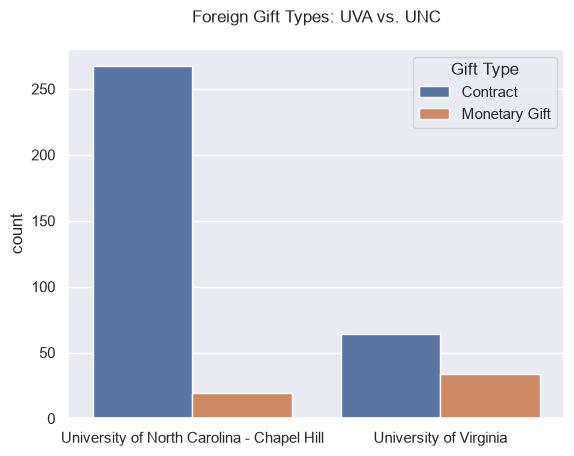

In [51]:
# Use seaborn's countplot to visualize distribution of gift types for UVA vs UNC
sns.countplot(data=uva_unc, x='Institution Name', hue='Gift Type')

plt.title('Foreign Gift Types: UVA vs. UNC\n')
plt.xlabel('')
plt.show()


In [27]:
# Keep donors who give to both, and who give more to UNC
unc_opp = donors.loc[(donors['University of Virginia'] > 0) & (donors['University of North Carolina - Chapel Hill'] > donors['University of Virginia'])]

unc_opp = unc_opp.reset_index()
unc_opp

# looks like there are 5 countries that give to both, but give more to UNC than UVA: England, France, Japan, Switzerland, and The Netherlands

Institution Name,Country of Giftor,University of North Carolina - Chapel Hill,University of Virginia
0,ENGLAND,2876760.0,1950666.0
1,FRANCE,2631412.0,250383.0
2,JAPAN,624156.0,265970.0
3,SWITZERLAND,5371435.0,2000000.0
4,THE NETHERLANDS,782946.0,725670.0


Now I'll make a quick plot to demonstrate these potential opportunities for UVA.

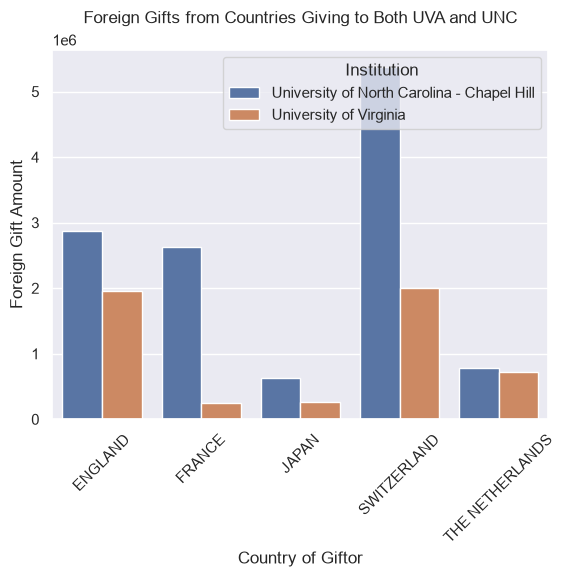

In [ ]:
# Need to reshape the dataframe first before plotting
unc_opp_reshape = unc_opp.melt(id_vars='Country of Giftor', var_name='Institution', value_name='Foreign Gift Amount')

# Change plotting aesthetics
sns.set(style="darkgrid")

sns.barplot(x='Country of Giftor', y='Foreign Gift Amount', hue='Institution', data=unc_opp_reshape)

plt.xticks(rotation=45)
plt.title("Foreign Gifts from Countries Giving to Both UVA and UNC\n")
plt.show()

In [53]:
# Comparing UVA to other Virginia schools
va_schools = ['Virginia Commonwealth University', 'College of William & Mary', 'Virginia Polytechnic Institute & State University', 'George Mason University', 'George Washington University']
va_schools_df = df[df['Institution Name'].isin(va_schools)]

va_schools_df['Institution Name'].value_counts()

va_stats = va_schools_df.groupby('Institution Name')['Foreign Gift Amount'].agg(['sum', 'mean', 'count', 'median'])
va_stats

va_schools_df.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount'].sum().reset_index().sort_values(['Institution Name', 'Foreign Gift Amount'],
        ascending=[True, False]).groupby('Institution Name').head(3) #reset index so that i can sort on dataframe
# groupby institution again to get top 3 giftors per institution



,Institution Name,Country of Giftor,Foreign Gift Amount
2,College of William & Mary,SAUDI ARABIA,2262530
1,College of William & Mary,CHINA,858350
0,College of William & Mary,CANADA,263618
10,George Mason University,SAUDI ARABIA,54183796
12,George Mason University,UNITED ARAB EMIRATES,6426436
6,George Mason University,KUWAIT,1388173
29,George Washington University,SAUDI ARABIA,77057518
15,George Washington University,BERMUDA,37530616
18,George Washington University,CHINA,6239338
51,Virginia Commonwealth University,QATAR,78867097


In [54]:
# Now add UVA for more direct comparison to other Virginia schools
uva_and_other_va = va_schools + ['University of Virginia']
uva_and_other_va_df = df[df['Institution Name'].isin(uva_and_other_va)]

va_stats = uva_and_other_va_df.groupby('Institution Name')['Foreign Gift Amount'].agg(['sum', 'mean', 'count', 'median'])
va_stats

,sum,mean,count,median
Institution Name,,,,
College of William & Mary,3384498,1.990881e+05,17,51600.0
George Mason University,65435604,1.721990e+06,38,507053.5
George Washington University,157668354,1.023820e+06,154,321237.0
University of Virginia,22189238,2.264208e+05,98,80535.5
Virginia Commonwealth University,89163583,7.753355e+05,115,33750.0
Virginia Polytechnic Institute & State University,11792062,4.913359e+05,24,350000.0


UVA seems to be on the low end in terms of total foreign gifts (ranked 4th out of these 6 Virginia schools, only higher than William & Mary and Virginia Tech). UVA is in the middle of the pack for foreign gift count, falling behind George Washington University and VCU. UVA's average gift amount is around 226k, though UVA's median gift amount is around 80k, which suggests they have some larger foreign gifts pulling this average up, which is an interesting note.

In [57]:
# Compare UVA to other Virginia schools in terms of gift types
va_schools_gift_types = uva_and_other_va_df.groupby(['Institution Name'])['Gift Type'].value_counts()
va_schools_gift_types

Institution Name                                   Gift Type    
College of William & Mary                          Monetary Gift     17
George Mason University                            Contract          38
George Washington University                       Contract         137
                                                   Monetary Gift     17
University of Virginia                             Contract          64
                                                   Monetary Gift     34
Virginia Commonwealth University                   Contract         115
Virginia Polytechnic Institute & State University  Contract          24
Name: count, dtype: int64

An interesting thing to note here is that George Mason, VCU, and VT engage in only contracts, no monetary gifts, and William & Mary's source is 100% monetary gifts. George Washington and UVA receive money from both sources, though George Washington heavily favors contracts. This might be a clue that UVA has an opportunity to expand foreign philanthropy by identifying sources that currently provide monetary gifts to other comparable institutions, but have limited or no monetary gift relationship with UVA.

Out of curiosity, I want to look more at institutions that receive a lot of monetary gifts, as this seems to be more of UVA's strong suit (compared to contracts), so it could be a solid strategy to look at other institutions who are doing a nice job of bringing in this type of gift, and see if UVA can mirror any of those actions.

In [ ]:
monetary_gifts = df[df['Gift Type'] == 'Monetary Gift']

# get some general stats about monetary gifts by institution
monetary_gifts.groupby('Institution Name')['Foreign Gift Amount'].agg(['sum', 'mean', 'count', 'median']).sort_values('sum', ascending=False)



,sum,mean,count,median
Institution Name,,,,
Harvard University,627333843,2.877678e+06,218,1000000.0
Massachusetts Institute of Technology,564038939,1.468851e+06,384,501500.0
Yale University,413388173,1.680440e+06,246,756874.0
Johns Hopkins University,412689952,5.057475e+05,816,84769.5
Stanford University,311516425,5.000264e+05,623,200000.0
...,...,...,...,...
University of Colorado Colorado Springs,33296,6.659200e+03,5,1200.0
"Rutgers, the State University of New Jersey",21830,1.091500e+04,2,10915.0
Western Michigan University,8065,3.360417e+02,24,27.5


Top five universities for total monetary gift amount received are Harvard University, MIT, Yale, Johns Hopkins, and Stanford. 

In [9]:
# Look at top giftor countries by country specifically for monetary gifts to see any potential targets for UVA
monetary_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)

Country of Giftor
HONG KONG           776795294
ENGLAND             680019307
CANADA              679932684
CHINA               469662761
INDIA               239686991
                      ...    
CROATIA                    26
SLOVAKIA                   20
NORTHERN IRELAND           15
UNITED NATIONS             10
ERITREA                     3
Name: Foreign Gift Amount, Length: 139, dtype: int64

Top countries for total monetary gift value are Hong Kong, England, and Canada. Possibly countries to target for UVA to increase monetary gifts.